## df_inventory - Assisted Housing Property Details: Cleaning & Exploration

`df_inventory` is the core property-level dataset in the AHI. Each row represents one **assisted housing development** in Alachua County — a residential property receiving some form of government or quasi-government support. With 168 columns, it covers everything from physical property characteristics and funding program flags to tenant demographics and neighborhood context drawn from the Census.

Because funding is tracked at the property level, a single development can be supported by multiple programs simultaneously. This makes the dataset richer but also more complex: a property may appear fully funded by one measure while carrying expiring contracts in another.

#### Column Groups

| Group | Key Columns | Description |
|-------|-------------|-------------|
| **Identifiers** | `Shim ID`, `FHFC Key`, `HUD REMS`, `Florida DOR Parcel` | IDs used by different agencies to track the same property |
| **Location** | `Development Name`, `Address`, `City`, `Zip Code`, `Census Tract`, `Latitude`/`Longitude` | Where the property is and how it maps to Census geographies |
| **Unit Counts** | `Total Units`, `Assisted Units`, `HUD/RD Rental Assistance Units`, `Public Housing ACC Units`, bedroom breakdowns | How many units exist and how many are actively assisted, broken down by size and assistance type |
| **Funder Flags** | `FHFC Funded`, `HUD Multifamily Funded`, `HUD Public Housing Funded`, `RD Funded`, `LHFA Funded` | Boolean indicators for which funders are attached to the property |
| **Programs** | `Housing Programs`, `Has Housing Credits 4%/9%`, `Has SAIL`, `Has Section 515`, etc. | Individual program flags and freetext program list; a property may carry multiple programs |
| **Program Timing** | Funding years, contract start dates, expiration dates per program | When each program began and when assistance is set to expire |
| **Property Details** | `Year Built`, `Owner Type`, `Construction Type`, `Total Living Area`, `Number of Buildings`, `REAC Score` | Physical and ownership characteristics; REAC scores apply only to HUD-funded properties |
| **Financial / Rent** | AMI-tiered units, average rents by bedroom size, `Average Rent/FMR Ratio`, utility allowances, sale price, just value | Rent levels relative to Fair Market Rent and distribution of units across income tiers |
| **Affordability Timeline** | `Affordability Start Date`, `Overall year of subsidy expiration`, `FHFC Preservation Set-Aside`, `In QCT 2022`, `In DDA 2022`, `RAD conversion` | When affordability began, when it may end, and flags for preservation risk |
| **Tenant Demographics** | Household size, % elderly, % with children, race/ethnicity, income distribution, AMI brackets | Characteristics of households currently living in the property |
| **Neighborhood Context** | Vacancy rates, homeownership/renter rates, racial demographics, housing values — at tract and county level | Census-derived neighborhood context, paired with county-level benchmarks for comparison |

**Area Median Income (AMI)** is the midpoint household income for a given region, used as a benchmark for affordability. Units at or below 30% AMI serve the lowest-income households; units above 80% AMI are generally considered market-rate even if they fall within an assisted property.

**Fair Market Rent (FMR)** is a HUD-published estimate of what a modest rental unit should cost in a given market. The `Average Rent/FMR ratio` compares a property's rents to this benchmark — a value below 1.0 suggests rents are being held below market rate, likely through a subsidy.

**REAC** (Real Estate Assessment Center) is HUD's inspection program. REAC scores rate the physical condition of HUD-assisted properties on a 0–100 scale.

**QCT** (Qualified Census Tract) and **DDA** (Difficult Development Area) are HUD-designated geographic categories used to allocate additional tax credit equity to affordable housing projects in high-cost or low-income areas.

**RAD** (Rental Assistance Demonstration) is a HUD program that converts older public housing contracts to long-term project-based rental assistance, often as part of a renovation or ownership transition.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import StrMethodFormatter

df_inventory = pd.read_csv("../Data/Cleaned Data/df_inventory.csv")
df_inventory.head()

,Shim ID,FHFC Key,HUD REMS,Public Housing Development #,Florida DOR Parcel,Development Name,Street Address,City,Zip Code,County,...,"% of Households with at least one child age 0-17, 2018-2022, Tract","% of Households with at least one child age 0-17, 2018-2022, County","% of Households with at least one person age 65 or older, 2018-2022, Tract","% of Households with at least one person age 65 or older, 2018-2022, County",Total Living Area,Number of Buildings,REAC Score (HUD only),REAC Inspection Date,Construction Type (FHFC Only)',In unincorporated area
0,1213,NaN,800003897.0,NaN,3.926002e+09,Alachua Apts,13605 NW County Road 235,Alachua,32615,Alachua,...,19.46,22.34,32.83,26.18,56979.0,15.0,96,2025-05-20,NaN,NaN
1,112,NaN,NaN,NaN,3.563000e+09,Alachua Villas,14000 NW 154TH AVE,Alachua,32615,Alachua,...,34.30,22.34,38.12,26.18,26660.0,9.0,NaN,NaN,NaN,NaN
2,7872,3308.0,NaN,NaN,3.214035e+09,Arbours at Merrillwood I,13207 NW 153rd Place,Alachua,32615,Alachua,...,39.30,22.34,25.72,26.18,NaN,NaN,NaN,NaN,NaN,NaN
3,7999,3454.0,NaN,NaN,3.926002e+09,Sherwood Oaks,13605 NW County Road 235,Alachua,32615,Alachua,...,19.46,22.34,32.83,26.18,NaN,NaN,NaN,NaN,Construction Category Not Found,NaN
4,1356,NaN,800004435.0,NaN,3.926020e+09,Sherwood Oaks Apartments,13400 NW 140th St,Alachua,32615,Alachua,...,19.46,22.34,32.83,26.18,48982.0,11.0,83b,2018-11-19,NaN,NaN


### Properties per Funder and Multi-Funder Overlap

`df_funder` showed us how many properties and units each funder covers in aggregate. Here we continue that analysis at the development level using `df_inventory`, which has a row for each individual development. We start with two simple bar charts to understand how funding is spread across the 60 developments in the dataset.

The first chart counts how many developments each funder flag covers — a development-level view of each funder's reach in Alachua County. The second shows how many funder flags each development carries, which tells us how often funding from multiple sources is stacked on the same development.

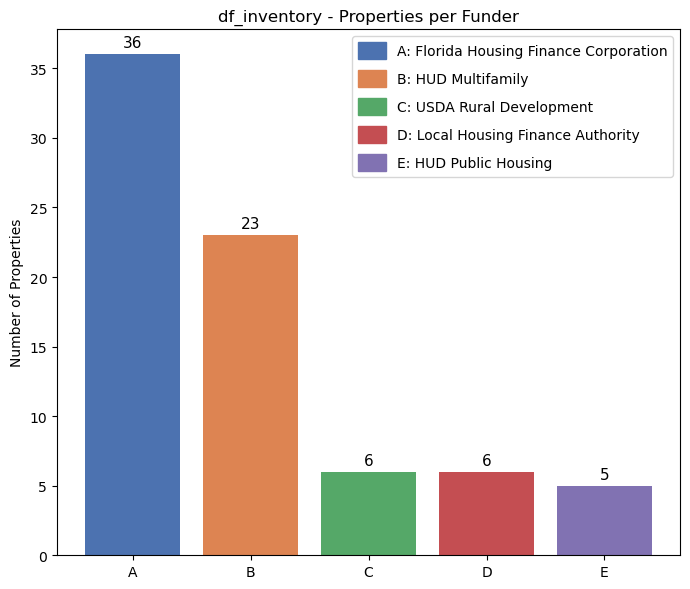

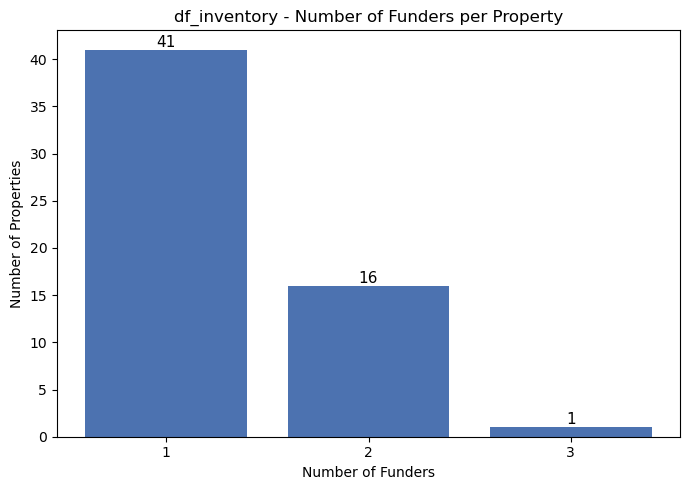

In [6]:
funder_cols = ["FHFC Funded", "HUD Multifamily Funded", "RD Funded", "LHFA Funded", "HUD Public Housing Funded"]

funder_labels = {
    "A": "Florida Housing Finance Corporation",
    "B": "HUD Multifamily",
    "C": "USDA Rural Development",
    "D": "Local Housing Finance Authority",
    "E": "HUD Public Housing"
}
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
codes = list(funder_labels.keys())
full_names = list(funder_labels.values())

# Chart 1: Properties per funder
prop_counts = [df_inventory[col].sum() for col in funder_cols]

legend_handles = [Patch(color=colors[i], label=f"{code}: {full_names[i]}") for i, code in enumerate(codes)]

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(codes, prop_counts, color=colors)
ax.bar_label(bars, fmt="%g", fontsize=11, padding=3)
ax.set_title("df_inventory - Properties per Funder")
ax.set_ylabel("Number of Properties")
ax.legend(handles=legend_handles, loc="upper right", fontsize=10, frameon=True, handlelength=2, handleheight=1.5, labelspacing=0.8)
plt.tight_layout()
plt.savefig("../Outputs/df_inventory/df_inventory_properties_per_funder.png", dpi=150, bbox_inches="tight")
plt.show()

# Chart 2: Number of funders per property
funder_count_per_property = df_inventory[funder_cols].sum(axis=1)
distribution = funder_count_per_property.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(distribution.index.astype(str), distribution.values, color="#4C72B0")
for i, v in enumerate(distribution.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=11)
ax.set_title("df_inventory - Number of Funders per Property")
ax.set_xlabel("Number of Funders")
ax.set_ylabel("Number of Properties")
plt.tight_layout()
plt.savefig("../Outputs/df_inventory/df_inventory_funder_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations

**Properties per Funder:**
- FHFC funds the most developments at 36, nearly matching all other funders combined.
- HUD Multifamily is a distant second at 23, with LHFA (6), USDA Rural Development (6), and HUD Public Housing (5) each covering a small share of the portfolio.
- These counts match `df_funder` exactly, confirming the two datasets are consistent at the development level.

**Number of Funders per Development:**
- Most developments (40 out of 60, 67%) are funded by exactly one source.
- 16 developments (27%) have two funders and one has three, showing that layered funding does exist but is not the norm.
- 3 developments show no funder flags at all, which is unexpected and likely reflects a data gap.

> **NOTE:** Investigate the 3 developments with no funder flags — they should have at least one funding source. Also worth examining which funders most commonly appear together on the same development.

### Which Developments Account for the Unassisted Unit Gap?

Across all 60 developments, there are 393 units that fall within a funded development but are not receiving assistance. Rather than being spread evenly, this gap is likely driven by a small number of developments. To test this, we use a **Pareto chart** — a bar chart sorted from largest to smallest, with a line showing the running cumulative percentage on a second axis. A dashed line marks the 80% threshold, which is the classic benchmark for identifying the "vital few" causes behind a problem.

C:\Users\yimol\AppData\Local\Temp\ipykernel_21232\2689939312.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n)


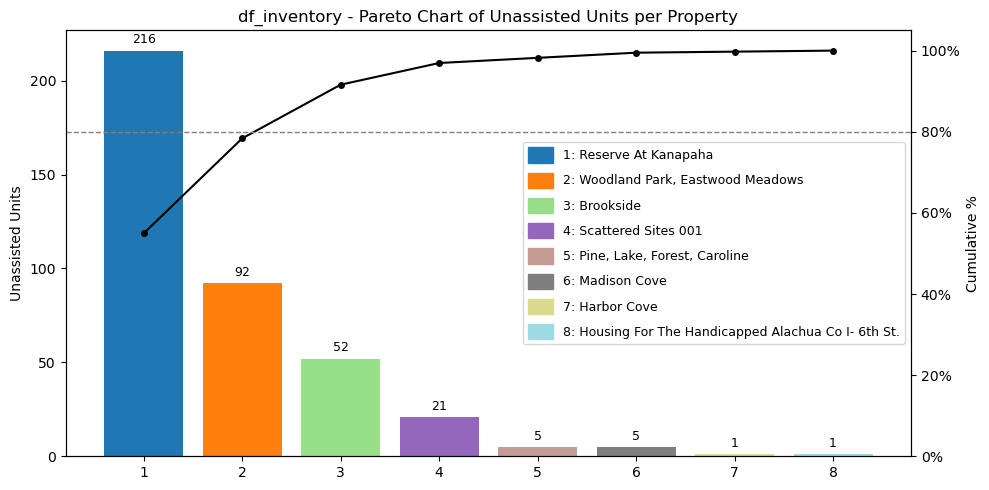

In [11]:
unassisted = (df_inventory["Total Units"] - df_inventory["Assisted Units"]).dropna()
unassisted = unassisted[unassisted > 0].sort_values(ascending=False)
names = df_inventory.loc[unassisted.index, "Development Name"].values
n = len(unassisted)

codes = [str(i + 1) for i in range(n)]
cmap = plt.cm.get_cmap("tab20", n)
colors = [cmap(i) for i in range(n)]

cumulative_pct = unassisted.cumsum() / unassisted.sum() * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(codes, unassisted.values, color=colors)
ax1.bar_label(bars, fmt="%g", fontsize=9, padding=3)
ax1.set_ylabel("Unassisted Units")
ax1.set_title("df_inventory - Pareto Chart of Unassisted Units per Property")

ax2 = ax1.twinx()
ax2.plot(codes, cumulative_pct.values, color="black", marker="o", markersize=4, linewidth=1.5)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:.0f}%"))

legend_handles = [Patch(color=colors[i], label=f"{codes[i]}: {names[i]}") for i in range(n)]
ax1.legend(handles=legend_handles, loc="center right", fontsize=9, frameon=True, handlelength=2, handleheight=1.5, labelspacing=0.8)

plt.tight_layout()
plt.savefig("../Outputs/df_inventory/df_inventory_unassisted_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations

- **Reserve at Kanapaha** alone accounts for 216 unassisted units — 55% of the total gap by itself.
- Adding **Woodland Park / Eastwood Meadows** (92 units) brings the cumulative to 78.4%, just under the 80% threshold.
- **Brookside** (52 units) pushes it to 91.6%, well past the threshold.
- The remaining 5 developments together account for only 33 units (8.4% combined).

The gap between total and assisted units in Alachua County is not a widespread issue — it is almost entirely driven by 2–3 developments. Whether this reflects mixed-income development design, expired assistance contracts, or another cause would require looking at those developments individually.

### Who Does Assisted Housing Serve? Units by Target Population

Each development in `df_inventory` is tagged with a `Target Population` describing who it is designed to serve. The possible values are **Family**, **Elderly**, **Persons with Disabilities**, and **Link** — where Link refers to units funded by FHFC and set aside for extremely low income households with special needs. A semicolon between values means a development serves multiple populations (e.g. `Elderly;Family` accepts both elderly residents and families).

Because units within a multi-population development are not broken down by population in this dataset, we treat each category as a whole. We use a **Pareto chart** to show which target populations account for the most units and how quickly they accumulate toward 100%.

C:\Users\yimol\AppData\Local\Temp\ipykernel_3988\3166669271.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n)


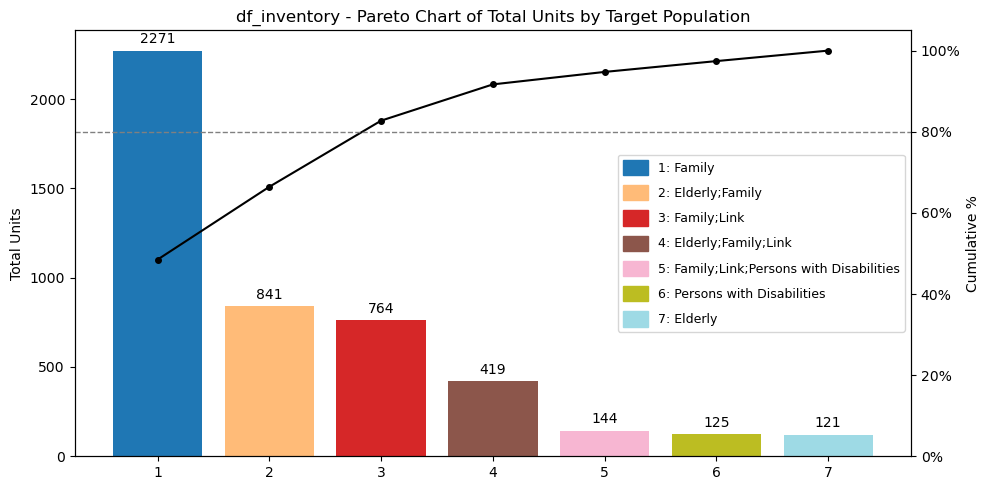

In [8]:
target_units = df_inventory.groupby("Target Population")["Total Units"].sum().sort_values(ascending=False)
labels = list(target_units.index)
values = list(target_units.values)
n = len(labels)

codes = [str(i + 1) for i in range(n)]
cmap = plt.cm.get_cmap("tab20", n)
colors = [cmap(i) for i in range(n)]

cumulative_pct = target_units.cumsum() / target_units.sum() * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(codes, values, color=colors)
ax1.bar_label(bars, fmt="%g", fontsize=10, padding=3)
ax1.set_ylabel("Total Units")
ax1.set_title("df_inventory - Pareto Chart of Total Units by Target Population")

ax2 = ax1.twinx()
ax2.plot(codes, cumulative_pct.values, color="black", marker="o", markersize=4, linewidth=1.5)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:.0f}%"))

legend_handles = [Patch(color=colors[i], label=f"{codes[i]}: {labels[i]}") for i in range(n)]
ax1.legend(handles=legend_handles, loc="center right", fontsize=9, frameon=True, handlelength=2, handleheight=1.5, labelspacing=0.8)

plt.tight_layout()
plt.savefig("../Outputs/df_inventory/df_inventory_target_population_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations

- **Family** alone accounts for 2,271 units — 48% of all 4,731 units in the dataset.
- Adding **Elderly;Family** (841 units) brings the cumulative to 65.8%, and **Family;Link** (764 units) pushes it to 81.9%, just crossing the 80% threshold.
- Unlike the unassisted units Pareto — where one development dominated at 55% — the distribution here is more gradual. Each of the top three categories contributes meaningfully rather than one dwarfing the rest.
- Every one of the top five categories includes "Family," confirming that family-oriented housing is the dominant model in Alachua County's assisted housing stock.
- Pure **Elderly** (121 units) and **Persons with Disabilities** (125 units) are each small in isolation, though Elderly appears as a component in two other categories (bars 2 and 4).

### Unit Size Distribution

The bedroom breakdown columns (`Number of 0 BR` through `Number of 4 or more BR`) tell us how many units of each size exist across all developments. Summing these across the dataset gives a picture of what household sizes the assisted housing stock is built to serve.

In [ ]:
br_cols = ["Number of 0 BR", "Number of 1 BR", "Number of 2 BR", "Number of 3 BR", "Number of 4 or more BR"]
br_labels = ["0 BR", "1 BR", "2 BR", "3 BR", "4+ BR"]
br_totals = [df_inventory[col].sum() for col in br_cols]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(br_labels, br_totals, color="#4C72B0")
ax.bar_label(bars, fmt="%g", fontsize=10, padding=3)
ax.set_title("df_inventory - Total Units by Bedroom Size")
ax.set_ylabel("Total Units")
plt.tight_layout()
plt.savefig("../Outputs/df_inventory/df_inventory_bedroom_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations

- The distribution is bell-shaped, peaking at **2 BR** (1,794 units), with 1 BR (1,224) and 3 BR (1,403) flanking it on either side.
- Studios (0 BR, 85 units) and 4+ BR units (74 units) are rare, indicating the stock is not strongly oriented toward single individuals or very large households.
- This shape is consistent with the target population findings — Family being the dominant category naturally produces a distribution centered on 2- and 3-bedroom units suited for small families.